In [18]:
pip install stargazer

Note: you may need to restart the kernel to use updated packages.


In [19]:
import pandas as pd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import HTML

df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",low_memory=False)

In [20]:
df["nonwhite"] = (df["perceived_race_code"] == 2).astype(int)

In [7]:
df["reason_1"] = df["reason_for_stop_code"].isin([1]).astype(int)

In [8]:
model1 = smf.ols(
    "searched ~ post_DGO + nonwhite",
    data=df
).fit(cov_type="HC1")


model2 = smf.ols(
    "searched ~ post_DGO + nonwhite + reason_1",
    data=df
).fit(cov_type="HC1")


model3 = smf.ols(
    """
    searched ~ post_DGO
              + nonwhite
              + reason_1
              + low_visibility
              + low_visibility:nonwhite
    """,
    data=df
).fit(cov_type="HC1")

model4 = smf.ols(
    """
    searched ~ post_DGO
              + nonwhite
              + reason_1
              + low_visibility
              + low_visibility:nonwhite
              + post_DGO:nonwhite
              + post_DGO:low_visibility
              + post_DGO:low_visibility:nonwhite 
    """,
    data=df
).fit(cov_type="HC1")

In [9]:
stargazer = Stargazer([model1, model2, model3, model4])

stargazer.title("DGO 9.07, Discretion, Visibility, and Racial Disparities in Search")

stargazer.rename_covariates({
    "post_DGO": "Policy (DGO 9.07)",
    "reason_1": "Pretextual Stop",
    "nonwhite": "Nonwhite",
    "low_visibility": "Low Visibility",
    "low_visibility:nonwhite": "Low Visibility × Nonwhite",
    "post_DGO:nonwhite": "Policy × Nonwhite",
    "post_DGO:low_visibility": "Policy × Low Visibility",
    "post_DGO:low_visibility:nonwhite": "Policy × Low Visibility × Nonwhite"
})

stargazer.add_custom_notes([
    "Robust standard errors in parentheses.",
    "Reason 1 includes pretextual stops such as equipment and administrative violations."
])

stargazer.significant_digits(3)

html_output = stargazer.render_html()

with open("regression_table_final.html", "w") as f:
    f.write(html_output)

display(HTML(html_output))

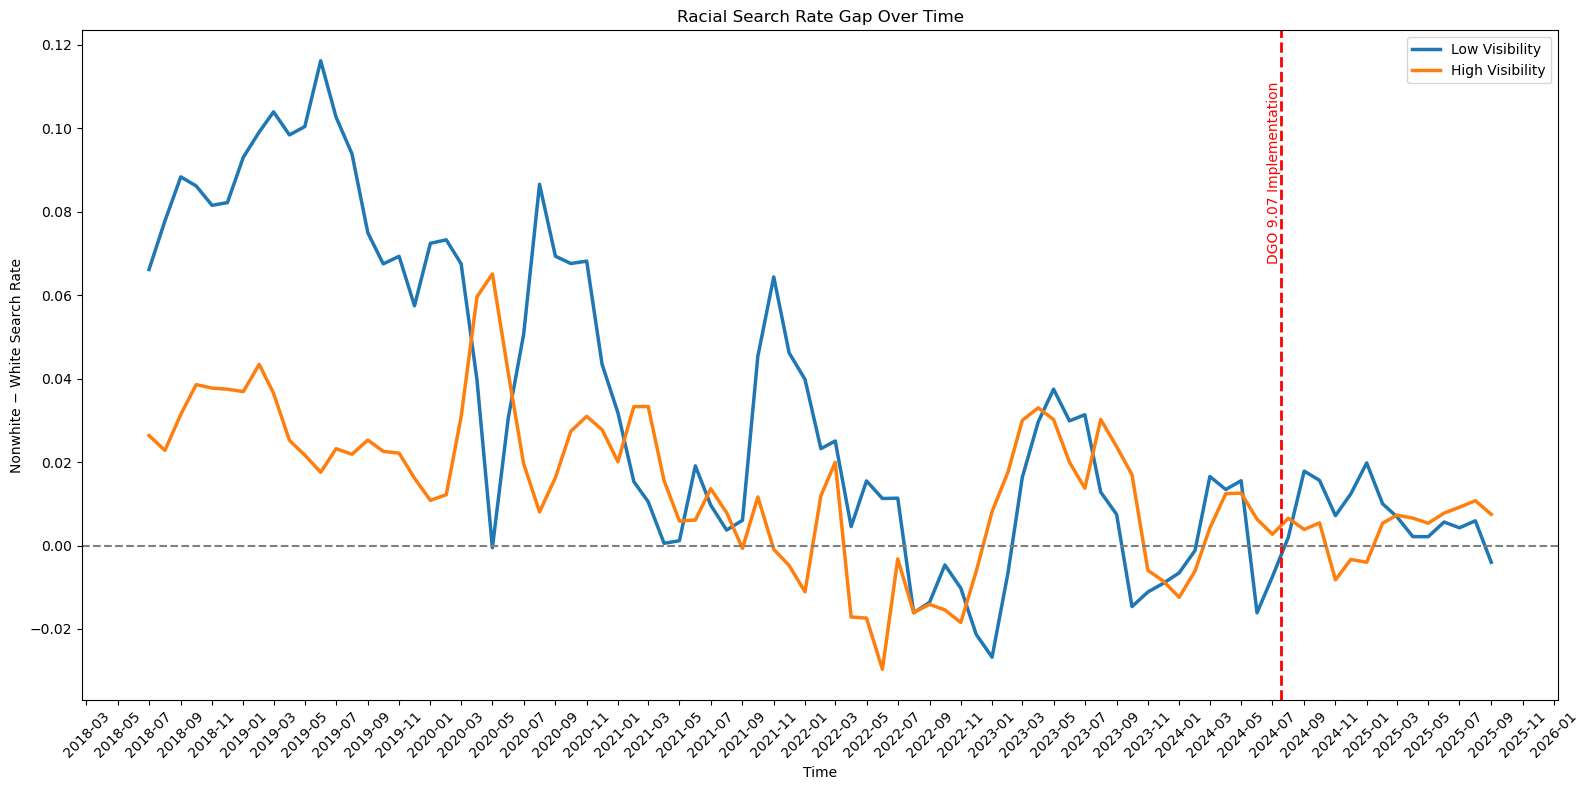

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)

df["date"] = pd.to_datetime(df["date"])

df = df[df["reason_for_stop_code"] == 1].copy()

df["white"] = (df["perceived_race_code"] == 7).astype(int)
df["nonwhite"] = 1 - df["white"]

df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

policy_date = pd.to_datetime("2024-07-17")

agg = (
    df.groupby(["month", "nonwhite", "low_visibility"])["searched"]
    .mean()
    .reset_index()
)

wide = agg.pivot_table(
    index=["month", "low_visibility"],
    columns="nonwhite",
    values="searched"
).reset_index()

wide["gap"] = wide[1] - wide[0]

high_gap = wide[wide["low_visibility"] == 0].copy().sort_values("month")
low_gap  = wide[wide["low_visibility"] == 1].copy().sort_values("month")

high_gap["gap_smooth"] = high_gap["gap"].rolling(
    3, center=True, min_periods=1
).mean()

low_gap["gap_smooth"] = low_gap["gap"].rolling(
    3, center=True, min_periods=1
).mean()

plt.figure(figsize=(16,8))

plt.plot(low_gap["month"], low_gap["gap_smooth"],
         linewidth=2.5, label="Low Visibility")

plt.plot(high_gap["month"], high_gap["gap_smooth"],
         linewidth=2.5, label="High Visibility")

plt.axvline(policy_date, color="red", linestyle="--", linewidth=2)

plt.text(
    policy_date,
    plt.ylim()[1]*0.9,
    "DGO 9.07 Implementation",
    color="red",
    rotation=90,
    va="top",
    ha="right"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1.5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.ylabel("Nonwhite − White Search Rate")
plt.xlabel("Time")
plt.title("Racial Search Rate Gap Over Time")
plt.legend()

plt.tight_layout()
plt.savefig("gap_visibility.png", dpi=300, bbox_inches="tight")
plt.show()

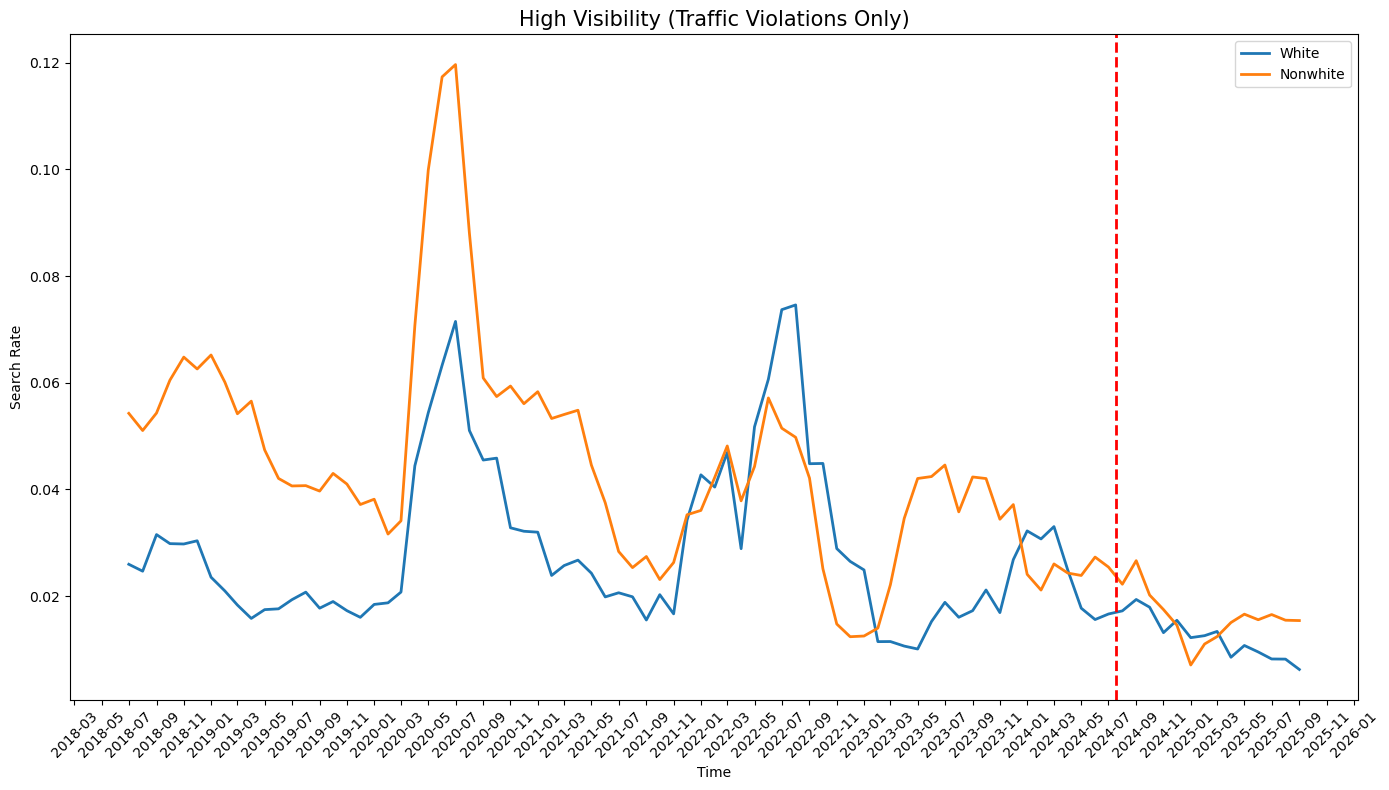

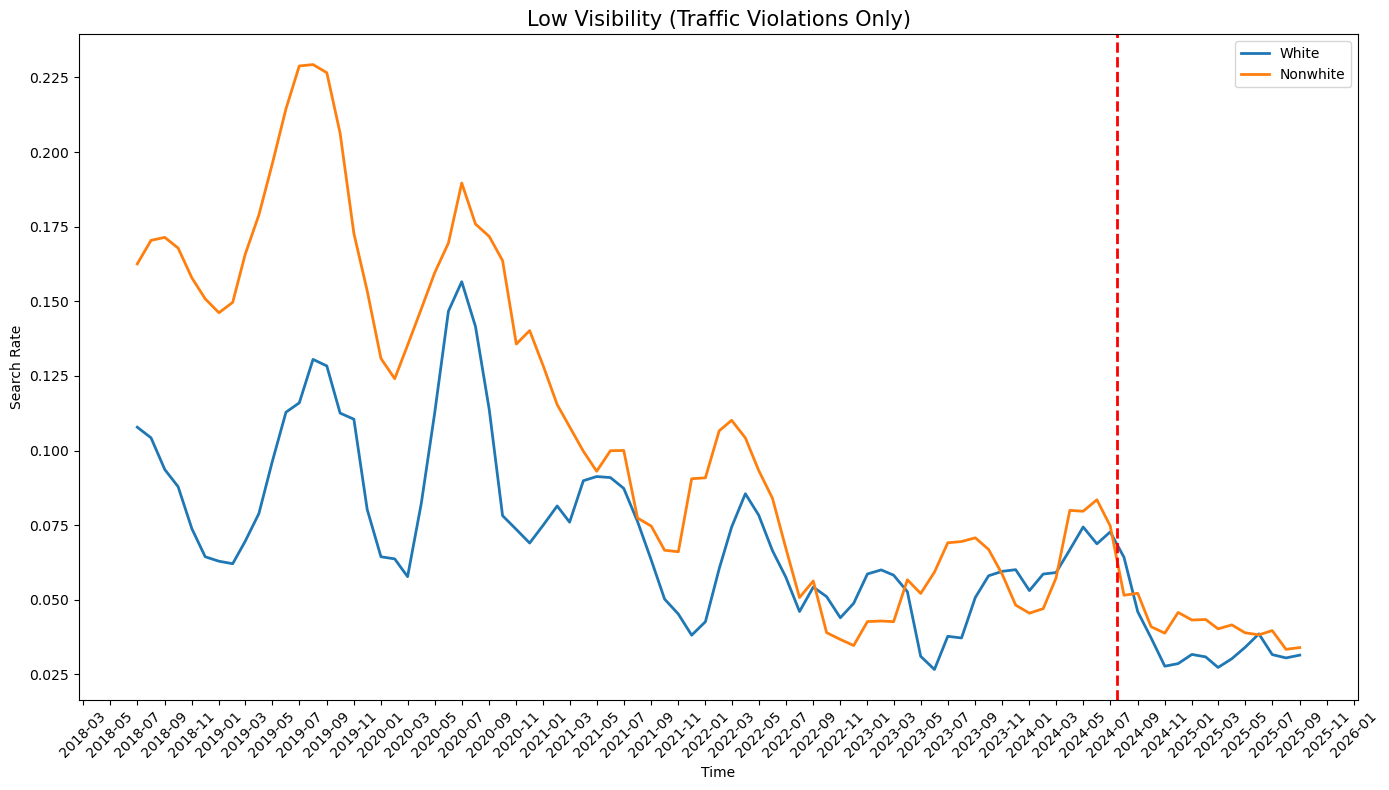

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)

df["date"] = pd.to_datetime(df["date"])

df = df[df["reason_for_stop_code"] == 1].copy()

df["white"] = (df["perceived_race_code"] == 7).astype(int)
df["nonwhite"] = 1 - df["white"]

df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

policy_date = pd.to_datetime("2024-07-17")

agg = (
    df.groupby(["month", "nonwhite", "low_visibility"])["searched"]
    .mean()
    .reset_index()
)

high_vis = agg[agg["low_visibility"] == 0].copy()
low_vis  = agg[agg["low_visibility"] == 1].copy()

# 4-month rolling smooth
high_vis["searched"] = high_vis.groupby("nonwhite")["searched"].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)

low_vis["searched"] = low_vis.groupby("nonwhite")["searched"].transform(
    lambda x: x.rolling(4, min_periods=1).mean()
)


plt.figure(figsize=(14,8))

for group, label in zip([0,1], ["White", "Nonwhite"]):
    temp = high_vis[high_vis["nonwhite"] == group]
    plt.plot(temp["month"], temp["searched"], linewidth=2, label=label)

plt.axvline(policy_date, color="red", linestyle="--", linewidth=2)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.title("High Visibility (Traffic Violations Only)", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Search Rate")
plt.legend()

plt.tight_layout()
plt.savefig("high_visibility.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14,8))

for group, label in zip([0,1], ["White", "Nonwhite"]):
    temp = low_vis[low_vis["nonwhite"] == group]
    plt.plot(temp["month"], temp["searched"], linewidth=2, label=label)

plt.axvline(policy_date, color="red", linestyle="--", linewidth=2)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

plt.title("Low Visibility (Traffic Violations Only)", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Search Rate")
plt.legend()

plt.tight_layout()
plt.savefig("low_visibility.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
df["reason_12"] = df["reason_for_stop_code"].isin([1, 2]).astype(int)
model1 = smf.ols(
    "searched ~ post_DGO + nonwhite",
    data=df
).fit(cov_type="HC1")


model2 = smf.ols(
    "searched ~ post_DGO + nonwhite + reason_12",
    data=df
).fit(cov_type="HC1")


model3 = smf.ols(
    """
    searched ~ post_DGO
              + nonwhite
              + reason_12
              + low_visibility
              + low_visibility:nonwhite
    """,
    data=df
).fit(cov_type="HC1")

model4 = smf.ols(
    """
    searched ~ post_DGO
              + nonwhite
              + reason_12
              + low_visibility
              + low_visibility:nonwhite
              + post_DGO:nonwhite
              + post_DGO:low_visibility
              + post_DGO:low_visibility:nonwhite 
    """,
    data=df
).fit(cov_type="HC1")
stargazer = Stargazer([model1, model2, model3, model4])

stargazer.title("DGO 9.07, Discretion, Visibility, and Racial Disparities in Search")

stargazer.rename_covariates({
    "post_DGO": "Policy (DGO 9.07)",
    "reason_12": "Low Discretion Stop",
    "nonwhite": "Nonwhite",
    "low_visibility": "Low Visibility",
    "low_visibility:nonwhite": "Low Visibility × Nonwhite",
    "post_DGO:nonwhite": "Policy × Nonwhite",
    "post_DGO:low_visibility": "Policy × Low Visibility",
    "post_DGO:low_visibility:nonwhite": "Policy × Low Visibility × Nonwhite"
})

stargazer.add_custom_notes([
    "Robust standard errors in parentheses.",
    "Reason 1/2 includes low-discretion stops such as equipment and administrative violations."
])

stargazer.significant_digits(3)

html_output = stargazer.render_html()

with open("regression_table_final + code2.html", "w") as f:
    f.write(html_output)

display(HTML(html_output))

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 8, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [13]:
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_csv(
    "/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
    low_memory=False
)

df["date"] = pd.to_datetime(df["date"])
policy_date = pd.to_datetime("2024-07-17")

df = df[df["reason_for_stop_code"] == 1].copy()

df = df[
    (df["date"] < policy_date) &
    (df["date"] >= policy_date - pd.DateOffset(years=3))
].copy()

df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)
df["month_index"] = df["date"].dt.to_period("M").astype(int)

In [14]:
df_high = df[df["low_visibility"] == 0].copy()

model_high = smf.ols(
    "searched ~ nonwhite + month_index + nonwhite:month_index",
    data=df_high
).fit(cov_type="HC1")

print("=== High Visibility Pre-Trend ===")
print(model_high.summary())

=== High Visibility Pre-Trend ===
                            OLS Regression Results                            
Dep. Variable:               searched   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     4.662
Date:                Mon, 09 Mar 2026   Prob (F-statistic):            0.00293
Time:                        22:36:30   Log-Likelihood:                 5654.9
No. Observations:               15107   AIC:                        -1.130e+04
Df Residuals:                   15103   BIC:                        -1.127e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [15]:
df_low = df[df["low_visibility"] == 1].copy()

model_low = smf.ols(
    "searched ~ nonwhite + month_index + nonwhite:month_index",
    data=df_low
).fit(cov_type="HC1")

print("=== Low Visibility Pre-Trend ===")
print(model_low.summary())

=== Low Visibility Pre-Trend ===
                            OLS Regression Results                            
Dep. Variable:               searched   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.918
Date:                Mon, 09 Mar 2026   Prob (F-statistic):              0.124
Time:                        22:36:30   Log-Likelihood:                 68.534
No. Observations:                8963   AIC:                            -129.1
Df Residuals:                    8959   BIC:                            -100.7
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [16]:
import pandas as pd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

# =====================================================
# 1. Load data
# =====================================================

df = pd.read_csv(
"/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
low_memory=False
)

# =====================================================
# 2. Create variables
# =====================================================

# datetime
df["stop_datetime"] = pd.to_datetime(df["stop_datetime"])

# policy implementation date
policy_date = pd.Timestamp("2024-07-17")

df["post_DGO"] = (df["stop_datetime"] >= policy_date).astype(int)

# race indicator
df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)

# discretionary stop (pretextual)
df["reason_1"] = df["reason_for_stop_code"].isin([1]).astype(int)

# visibility indicator
df["low_visibility"] = (df["is_daylight"] == 0).astype(int)

# remove missing observations
df = df.dropna(subset=[
"searched",
"post_DGO",
"nonwhite",
"reason_1",
"low_visibility"
])

# =====================================================
# 3. Regression helper
# =====================================================

def fit_ols(formula, data):

    return smf.ols(
        formula,
        data=data
    ).fit(
        cov_type="HC1"
    )

# =====================================================
# TABLE A — Policy Effect on Racial Disparity
# =====================================================

# (1) Baseline disparity
A1 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
""",
df
)

# (2) Policy × race
A2 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + post_DGO:nonwhite
""",
df
)

# (3) Add visibility control
A3 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + low_visibility
          + post_DGO:nonwhite
""",
df
)

# (4) Allow disparity to vary by visibility
A4 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
          + post_DGO:nonwhite
""",
df
)

# =====================================================
# TABLE B — Veil of Darkness Mechanism
# =====================================================

# (1) Visibility baseline
B1 = fit_ols(
"""
searched ~ nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
""",
df
)

# (2) Add policy baseline
B2 = fit_ols(
"""
searched ~ nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
          + post_DGO
""",
df
)

# (3) Triple difference
B3 = fit_ols(
"""
searched ~ nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
          + post_DGO
          + post_DGO:low_visibility
          + post_DGO:nonwhite
          + post_DGO:low_visibility:nonwhite
""",
df
)

# (4) Pretextual stop mechanism
B4 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + low_visibility
          + post_DGO:reason_1
          + post_DGO:reason_1:nonwhite
""",
df
)

# =====================================================
# 4. TABLE A OUTPUT
# =====================================================

stargazer_A = Stargazer([A1, A2, A3, A4])

stargazer_A.title(
"Table A: Policy Effect on Racial Disparities in Search"
)

stargazer_A.rename_covariates({

"post_DGO":"Post Policy (DGO 9.07)",

"nonwhite":"Nonwhite",

"reason_1":"Pretextual Stop",

"low_visibility":"Low Visibility",

"post_DGO:nonwhite":"Policy × Nonwhite",

"nonwhite:low_visibility":"Nonwhite × Low Visibility"

})

stargazer_A.add_custom_notes([
"Robust standard errors in parentheses.",
"Policy implemented July 17, 2024."
])

stargazer_A.significant_digits(3)

display(HTML(stargazer_A.render_html()))

# =====================================================
# 5. TABLE B OUTPUT
# =====================================================

stargazer_B = Stargazer([B1, B2, B3, B4])

stargazer_B.title(
"Table B: Veil of Darkness and Discretion Mechanisms"
)

stargazer_B.rename_covariates({

"post_DGO":"Post Policy (DGO 9.07)",

"nonwhite":"Nonwhite",

"reason_1":"Pretextual Stop",

"low_visibility":"Low Visibility",

"nonwhite:low_visibility":"Nonwhite × Low Visibility",

"post_DGO:low_visibility":"Policy × Low Visibility",

"post_DGO:nonwhite":"Policy × Nonwhite",

"post_DGO:low_visibility:nonwhite":"Policy × Low Visibility × Nonwhite",

"post_DGO:reason_1":"Policy × Pretextual Stop",

"post_DGO:reason_1:nonwhite":"Policy × Pretextual Stop × Nonwhite"

})

stargazer_B.add_custom_notes([
"Robust standard errors in parentheses.",
"Table B implements the veil-of-darkness test."
])

stargazer_B.significant_digits(3)

display(HTML(stargazer_B.render_html()))

In [17]:
import pandas as pd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

# =====================================================
# 1. Load data
# =====================================================

df = pd.read_csv(
"/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv",
low_memory=False
)

# =====================================================
# 2. Create variables
# =====================================================

# datetime
df["stop_datetime"] = pd.to_datetime(df["stop_datetime"])

# policy implementation date
policy_date = pd.Timestamp("2024-07-17")

df["post_DGO"] = (df["stop_datetime"] >= policy_date).astype(int)

# race indicator
df["nonwhite"] = (df["perceived_race_code"] != 7).astype(int)

# discretionary stop (pretextual)
df["reason_1"] = df["reason_for_stop_code"].isin([1]).astype(int)

# visibility indicator
df["low_visibility"] = (df["is_daylight"] == 0).astype(int)

# remove missing observations
df = df.dropna(subset=[
"searched",
"post_DGO",
"nonwhite",
"reason_1",
"low_visibility"
])

# =====================================================
# 3. Regression helper
# =====================================================

def fit_ols(formula, data):

    return smf.ols(
        formula,
        data=data
    ).fit(
        cov_type="HC1"
    )

# =====================================================
# TABLE A — Policy Effect on Racial Disparity
# =====================================================

# (1) Baseline disparity
A1 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
""",
df
)

# (2) Policy × race
A2 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + post_DGO:nonwhite
""",
df
)

# (3) Add visibility control
A3 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + low_visibility
          + post_DGO:nonwhite
""",
df
)

# (4) Allow disparity to vary by visibility
A4 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
          + post_DGO:nonwhite
""",
df
)

# =====================================================
# TABLE B — Veil of Darkness Mechanism
# =====================================================

# (1) Visibility baseline
B1 = fit_ols(
"""
searched ~ nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
""",
df
)

# (2) Add policy baseline
B2 = fit_ols(
"""
searched ~ nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
          + post_DGO
""",
df
)

# (3) Triple difference
B3 = fit_ols(
"""
searched ~ nonwhite
          + reason_1
          + low_visibility
          + nonwhite:low_visibility
          + post_DGO
          + post_DGO:low_visibility
          + post_DGO:nonwhite
          + post_DGO:low_visibility:nonwhite
""",
df
)

# (4) Pretextual stop mechanism
B4 = fit_ols(
"""
searched ~ post_DGO
          + nonwhite
          + reason_1
          + low_visibility
          + post_DGO:reason_1
          + post_DGO:reason_1:nonwhite
""",
df
)

# =====================================================
# 4. TABLE A OUTPUT
# =====================================================

stargazer_A = Stargazer([A1, A2, A3, A4])

stargazer_A.title(
"Table A: Policy Effect on Racial Disparities in Search"
)

stargazer_A.rename_covariates({

"post_DGO":"Post Policy (DGO 9.07)",

"nonwhite":"Nonwhite",

"reason_1":"Pretextual Stop",

"low_visibility":"Low Visibility",

"post_DGO:nonwhite":"Policy × Nonwhite",

"nonwhite:low_visibility":"Nonwhite × Low Visibility"

})

stargazer_A.add_custom_notes([
"Robust standard errors in parentheses.",
"Policy implemented July 17, 2024."
])

stargazer_A.significant_digits(3)

display(HTML(stargazer_A.render_html()))

# =====================================================
# 5. TABLE B OUTPUT
# =====================================================

stargazer_B = Stargazer([B1, B2, B3, B4])

stargazer_B.title(
"Table B: Veil of Darkness and Discretion Mechanisms"
)

stargazer_B.rename_covariates({

"post_DGO":"Post Policy (DGO 9.07)",

"nonwhite":"Nonwhite",

"reason_1":"Pretextual Stop",

"low_visibility":"Low Visibility",

"nonwhite:low_visibility":"Nonwhite × Low Visibility",

"post_DGO:low_visibility":"Policy × Low Visibility",

"post_DGO:nonwhite":"Policy × Nonwhite",

"post_DGO:low_visibility:nonwhite":"Policy × Low Visibility × Nonwhite",

"post_DGO:reason_1":"Policy × Pretextual Stop",

"post_DGO:reason_1:nonwhite":"Policy × Pretextual Stop × Nonwhite"

})

stargazer_B.add_custom_notes([
"Robust standard errors in parentheses.",
"Table B implements the veil-of-darkness test."
])

stargazer_B.significant_digits(3)

display(HTML(stargazer_B.render_html()))

In [18]:
path = "/Users/thisisjasmine/Desktop/"

with open(path + "TableA_policy_effect.html", "w") as f:
    f.write(stargazer_A.render_html())

with open(path + "TableB_mechanism.html", "w") as f:
    f.write(stargazer_B.render_html())

## Regression Specifications

### Table A: Policy Effect on Racial Disparities in Police Searches

This table evaluates whether the implementation of **DGO 9.07** reduced racial disparities in search decisions.

---

### (A1) Baseline Disparity

$$
Search_i =
\beta_0 +
\beta_1 Policy_i +
\beta_2 Nonwhite_i +
\beta_3 Pretext_i +
\epsilon_i
$$

---

### (A2) Policy × Race

$$
Search_i =
\beta_0 +
\beta_1 Policy_i +
\beta_2 Nonwhite_i +
\beta_3 Pretext_i +
\beta_4 (Policy_i \times Nonwhite_i) +
\epsilon_i
$$

Key coefficient:

$$
\beta_4
$$

This measures whether racial disparities changed after the policy.

---

### (A3) Controlling for Visibility

$$
Search_i =
\beta_0 +
\beta_1 Policy_i +
\beta_2 Nonwhite_i +
\beta_3 Pretext_i +
\beta_4 LowVisibility_i +
\beta_5 (Policy_i \times Nonwhite_i) +
\epsilon_i
$$

---

### (A4) Racial Disparity under Different Visibility Conditions

$$
Search_i =
\beta_0 +
\beta_1 Policy_i +
\beta_2 Nonwhite_i +
\beta_3 Pretext_i +
\beta_4 LowVisibility_i +
\beta_5 (Nonwhite_i \times LowVisibility_i) +
\beta_6 (Policy_i \times Nonwhite_i) +
\epsilon_i
$$

---

# Table B: Veil-of-Darkness and Discretion Mechanisms

This table tests whether racial disparities depend on **driver visibility (the veil-of-darkness test)** and whether discretionary stops contribute to these disparities.

---

### (B1) Visibility Baseline

$$
Search_i =
\beta_0 +
\beta_1 Nonwhite_i +
\beta_2 Pretext_i +
\beta_3 LowVisibility_i +
\beta_4 (Nonwhite_i \times LowVisibility_i) +
\epsilon_i
$$

Key coefficient:

$$
\beta_4
$$

This measures whether racial disparities differ between daylight and low-visibility conditions.

---

### (B2) Add Policy Baseline

$$
Search_i =
\beta_0 +
\beta_1 Nonwhite_i +
\beta_2 Pretext_i +
\beta_3 LowVisibility_i +
\beta_4 (Nonwhite_i \times LowVisibility_i) +
\beta_5 Policy_i +
\epsilon_i
$$

---

### (B3) Triple Difference (Veil-of-Darkness Test)

$$
Search_i =
\beta_0 +
\beta_1 Nonwhite_i +
\beta_2 Pretext_i +
\beta_3 LowVisibility_i +
\beta_4 (Nonwhite_i \times LowVisibility_i) +
\beta_5 Policy_i +
\beta_6 (Policy_i \times LowVisibility_i) +
\beta_7 (Policy_i \times Nonwhite_i) +
\beta_8 (Policy_i \times LowVisibility_i \times Nonwhite_i) +
\epsilon_i
$$

Key coefficient:

$$
\beta_8
$$

This tests whether the policy reduced **visibility-based racial disparities**.

---

### (B4) Pretextual Stop Mechanism

$$
Search_i =
\beta_0 +
\beta_1 Policy_i +
\beta_2 Nonwhite_i +
\beta_3 Pretext_i +
\beta_4 LowVisibility_i +
\beta_5 (Policy_i \times Pretext_i) +
\beta_6 (Policy_i \times Pretext_i \times Nonwhite_i) +
\epsilon_i
$$

Key coefficients:

$$
\beta_5 ,\ \beta_6
$$

These measure whether the policy changed search behavior during **discretionary (pretextual) stops**, particularly for nonwhite drivers.

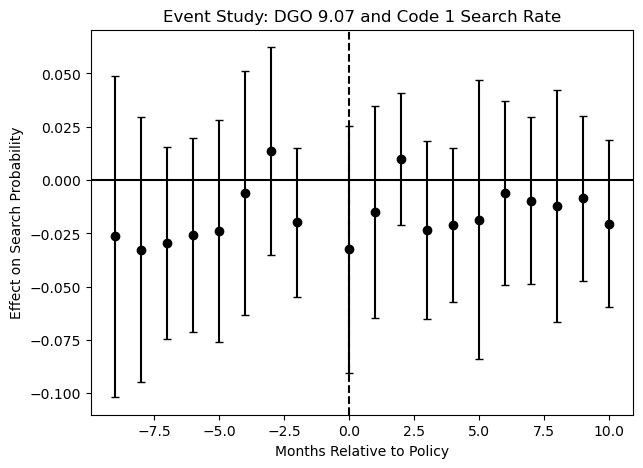

In [46]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

df = df.copy()

df["stop_datetime"] = pd.to_datetime(df["stop_datetime"])
df["month"] = df["stop_datetime"].dt.to_period("M")

policy_month = pd.Period("2024-07", freq="M")

df["event_time"] = (df["month"] - policy_month).apply(lambda x: x.n)
df["month_fe"] = df["month"].astype(str)

# Code 1 stops
df_code1 = df[df["reason_for_stop_code"] == 1].copy()

# window
df_event = df_code1[(df_code1["event_time"] >= -10) &
                    (df_code1["event_time"] <= 10)].copy()

df_event = df_event.dropna(subset=["district"])
df_event["district"] = df_event["district"].astype(str)

# regression
model = smf.ols(
    "searched ~ C(event_time)*nonwhite + C(district) + C(month_fe)",
    data=df_event
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_event["district"]}
)

# extract interaction coefficients
coefs = model.params.filter(like="event_time").filter(like="nonwhite")
ses = model.bse.filter(like="event_time").filter(like="nonwhite")

times = [int(i.split("[T.")[1].split("]")[0]) for i in coefs.index]

order = np.argsort(times)

times = np.array(times)[order]
coefs = coefs.values[order]
ses = ses.values[order]

# remove baseline
mask = times != -1
times = times[mask]
coefs = coefs[mask]
ses = ses[mask]

# plot
plt.figure(figsize=(7,5))

plt.errorbar(
    times,
    coefs,
    yerr=1.96*ses,
    fmt="o",
    color="black",
    capsize=3
)

plt.axhline(0, color="black")
plt.axvline(0, linestyle="--", color="black")

plt.xlabel("Months Relative to Policy")
plt.ylabel("Effect on Search Probability")
plt.title("Event Study: DGO 9.07 and Code 1 Search Rate")

plt.show()

In [50]:
coef_names = [c for c in model.params.index 
              if "event_time" in c and "nonwhite" in c]

pre_coefs = [c for c in coef_names 
             if int(c.split("[T.")[1].split("]")[0]) < 0]

print("Pre-period coefficients:")
print(pre_coefs)

hypothesis = " = 0, ".join(pre_coefs) + " = 0"

print("\nJoint test:")
print(hypothesis)

print(model.f_test(hypothesis))

Pre-period coefficients:
['C(event_time)[T.-9]:nonwhite', 'C(event_time)[T.-8]:nonwhite', 'C(event_time)[T.-7]:nonwhite', 'C(event_time)[T.-6]:nonwhite', 'C(event_time)[T.-5]:nonwhite', 'C(event_time)[T.-4]:nonwhite', 'C(event_time)[T.-3]:nonwhite', 'C(event_time)[T.-2]:nonwhite', 'C(event_time)[T.-1]:nonwhite']

Joint test:
C(event_time)[T.-9]:nonwhite = 0, C(event_time)[T.-8]:nonwhite = 0, C(event_time)[T.-7]:nonwhite = 0, C(event_time)[T.-6]:nonwhite = 0, C(event_time)[T.-5]:nonwhite = 0, C(event_time)[T.-4]:nonwhite = 0, C(event_time)[T.-3]:nonwhite = 0, C(event_time)[T.-2]:nonwhite = 0, C(event_time)[T.-1]:nonwhite = 0
<F test: F=2.3483067267117677, p=0.09989103532369328, df_denom=10, df_num=9>


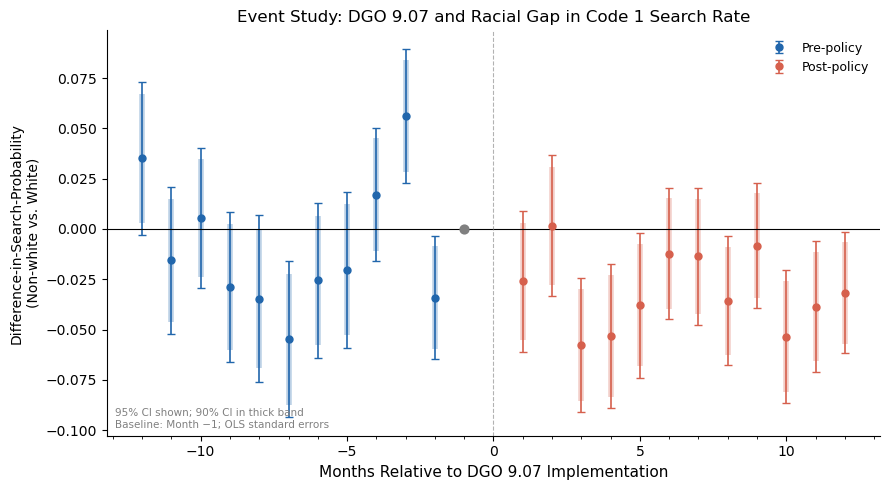

In [24]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import re

# ── 数据准备 ──────────────────────────────────────────
df = df.copy()
df["stop_datetime"] = pd.to_datetime(df["stop_datetime"])
df["month"] = df["stop_datetime"].dt.to_period("M")

policy_month = pd.Period("2024-07", freq="M")
df["event_time"] = (df["month"] - policy_month).apply(lambda x: x.n)
df["month_fe"] = df["month"].astype(str)

WINDOW = 12
mask = df["event_time"].between(-WINDOW, WINDOW) & (df["event_time"] != 0)
df_event = df[mask & (df["reason_for_stop_code"] == 1)].dropna(subset=["district"]).copy()
df_event["district"] = df_event["district"].astype(str)

assert df_event["event_time"].isin([-1]).any(), "基准期 -1 不存在，请检查数据"

# ── 回归 ──────────────────────────────────────────────
model = smf.ols(
    "searched ~ C(event_time, Treatment(-1))*nonwhite + C(district) + C(month_fe)",
    data=df_event
).fit()

# ── 系数提取 ──────────────────────────────────────────
def extract_event_coefs(model, interaction_term="nonwhite"):
    params = model.params
    bse = model.bse

    mask = params.index.str.contains("event_time") & \
           params.index.str.contains(interaction_term)

    coefs = params[mask]
    ses = bse[mask]

    def parse_time(s):
        match = re.search(r"\[T\.(-?\d+)\]", s)
        return int(match.group(1)) if match else None

    times = [parse_time(i) for i in coefs.index]
    valid = [(t, c, s) for t, c, s in zip(times, coefs.values, ses.values) if t is not None]
    times, coef_vals, se_vals = zip(*valid)

    df_out = pd.DataFrame({
        "time": times,
        "coef": coef_vals,
        "se": se_vals
    }).sort_values("time").reset_index(drop=True)

    baseline = pd.DataFrame({"time": [-1], "coef": [0.0], "se": [0.0]})
    df_out = pd.concat([df_out, baseline]).sort_values("time").reset_index(drop=True)

    return df_out

results = extract_event_coefs(model)

# ── 画图 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

pre  = results[results["time"] < 0]
post = results[results["time"] > 0]

for subset, color, label in [
    (pre,  "#2166ac", "Pre-policy"),
    (post, "#d6604d", "Post-policy"),
]:
    # 90% CI（粗带）
    ax.errorbar(
        subset["time"], subset["coef"],
        yerr=1.645 * subset["se"],
        fmt="none", color=color, alpha=0.3, capsize=0, linewidth=4,
    )
    # 95% CI
    ax.errorbar(
        subset["time"], subset["coef"],
        yerr=1.96 * subset["se"],
        fmt="o", color=color, capsize=3, linewidth=1.2,
        markersize=5, label=label
    )

# 基준期
ax.scatter([-1], [0], color="gray", zorder=5, s=40)

ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, linestyle="--", color="gray", linewidth=0.8, alpha=0.6)

ax.set_xlabel("Months Relative to DGO 9.07 Implementation", fontsize=11)
ax.set_ylabel("Difference-in-Search-Probability\n(Non-white vs. White)", fontsize=10)
ax.set_title("Event Study: DGO 9.07 and Racial Gap in Code 1 Search Rate", fontsize=12)

ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

ax.annotate(
    "95% CI shown; 90% CI in thick band\n"
    "Baseline: Month −1; OLS standard errors",
    xy=(0.01, 0.02), xycoords="axes fraction",
    fontsize=7.5, color="gray"
)

plt.tight_layout()
plt.savefig("event_study_dgo907.pdf", dpi=300, bbox_inches="tight")
plt.show()